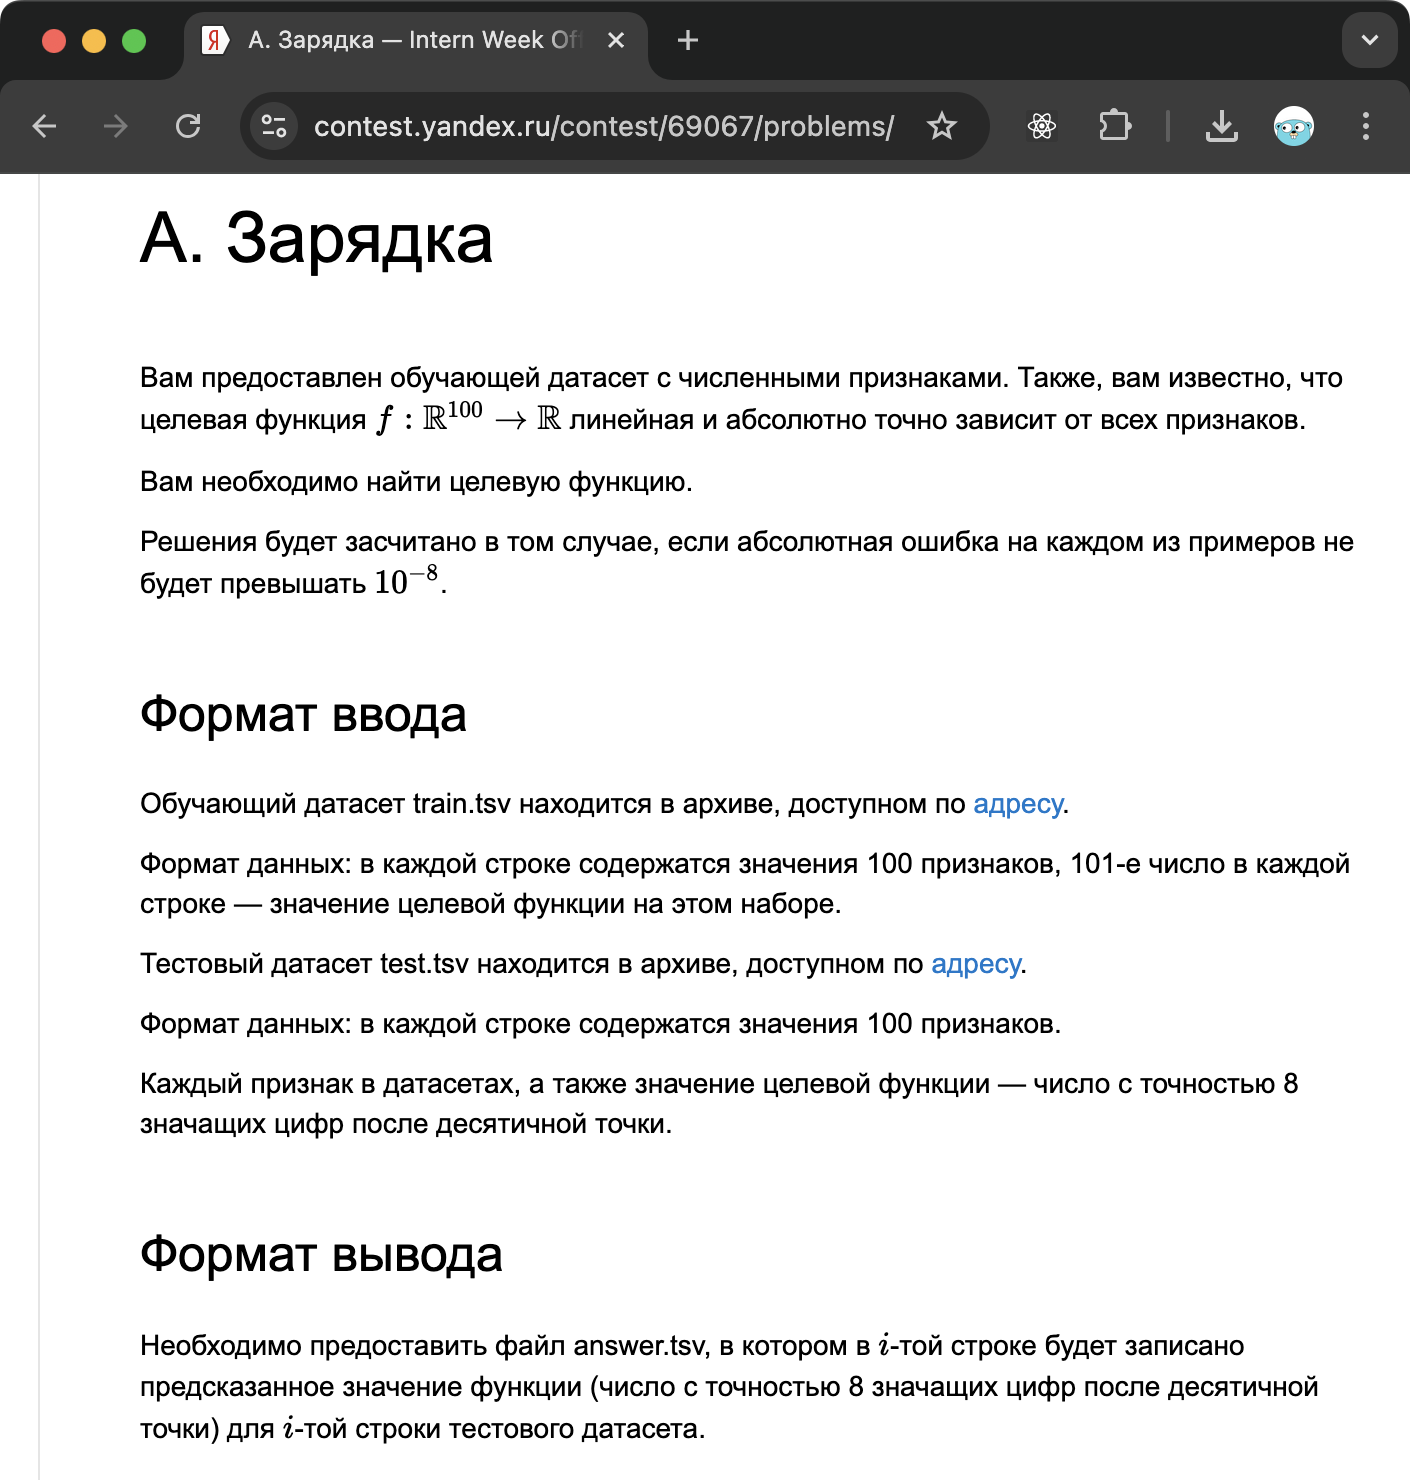

In [13]:
import numpy as np
import pandas as pd

# Загрузка данных
train_data = pd.read_csv('train.tsv', sep='\t', header=None)
test_data = pd.read_csv('test.tsv', sep='\t', header=None)

# Разделение данных на признаки и целевую переменную
X_train = train_data.iloc[:, :-1].values  # 100 признаков
y_train = train_data.iloc[:, -1].values   # Целевая переменная

# Модель линейной регрессии
X_train_bias = np.hstack([X_train, np.ones((X_train.shape[0], 1))])  # Добавляем столбец для свободного члена
coefficients = np.linalg.lstsq(X_train_bias, y_train, rcond=None)[0]

# Обработка тестового датасета
X_test = test_data.values
X_test_bias = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

# Предсказания на тестовом наборе
test_predictions = X_test_bias @ coefficients

# Сохранение предсказаний в файл answer.tsv с точностью 8 знаков после запятой
pd.DataFrame(test_predictions).to_csv('answer.tsv', sep='\t', index=False, header=False, float_format='%.8f')
